Failed encoding utf-8: 'utf-8' codec can't decode byte 0xa3 in position 16: invalid start byte
Failed encoding utf-8-sig: 'utf-8' codec can't decode byte 0xa3 in position 7092: invalid start byte
Loaded /content/Stock News Dataset.csv with encoding=cp1252, shape=(4101, 27)
After combining: (4101, 28)
Label distribution:
 Label
1    2166
0    1935
Name: count, dtype: int64
IQR bounds: -292.5 .. 879.5
Outlier count: 0


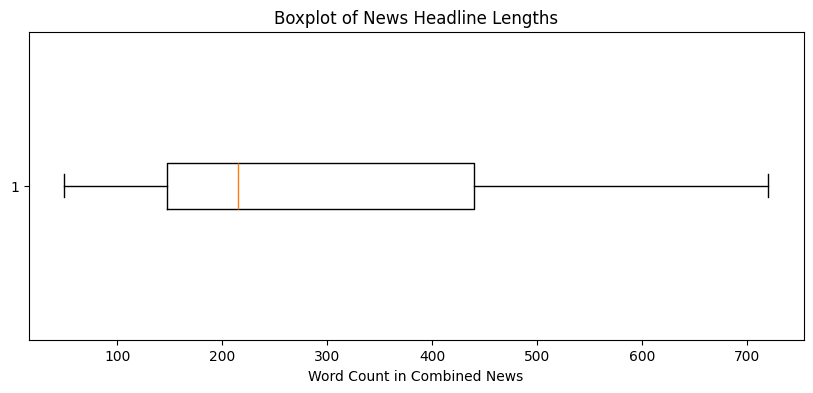

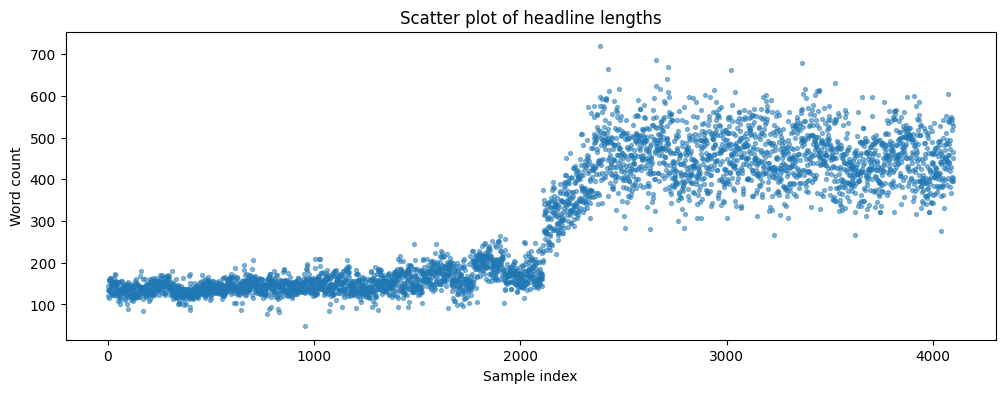

TF-IDF shape: (4101, 5000)


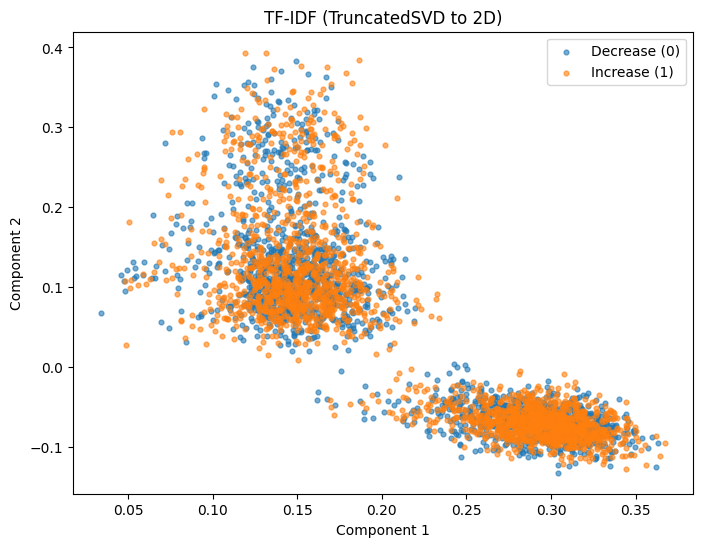

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     1,280,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,281 (5.01 MB)

 Trainable params: 1,313,281 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.5129 - loss: 0.6924 - val_accuracy: 0.5061 - val_loss: 0.6948
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5757 - loss: 0.6679 - val_accuracy: 0.5061 - val_loss: 0.7143
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8272 - loss: 0.4716 - val_accuracy: 0.5152 - val_loss: 0.8799
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9437 - loss: 0.2063 - val_accuracy: 0.4939 - val_loss: 1.2311
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9902 - loss: 0.0654 - val_accuracy: 0.5030 - val_loss: 1.5660
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.4494    0.4470    0.4482       387
           1     0.5092    0.5115    0.5103       434

    accuracy                         0.4811       821
   macro avg     0.4793    0.4793    0.4793       821
weighted avg     0.4810    0

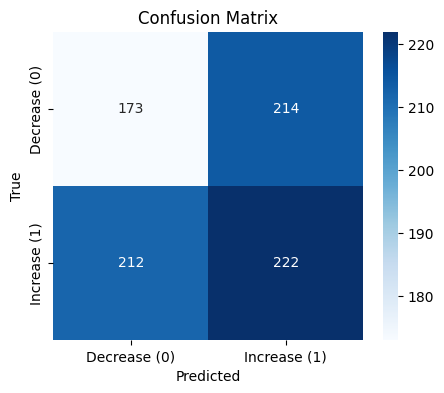

In [ ]:
# ======= Colab-ready: install dependencies =======
!pip -q install scikit-learn pandas matplotlib nltk joblib tensorflow seaborn

# ======= Imports =======
import os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import TruncatedSVD

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# ======= 0) Load CSV =======
CSV_PATH = "/content/Stock News Dataset.csv"  # adjust if needed
missing_values = ["?", "N/A", "na", "null", " ", ""]

def load_csv(path):
    for enc in ("utf-8", "utf-8-sig", "cp1252", "latin1"):
        try:
            df = pd.read_csv(path, encoding=enc, na_values=missing_values)
            print(f"Loaded {path} with encoding={enc}, shape={df.shape}")
            return df
        except Exception as e:
            print(f"Failed encoding {enc}: {e}")
    raise RuntimeError("Could not load CSV.")

df = load_csv(CSV_PATH)

# ======= 1) Combine headlines =======
headline_cols = [f"Top{i}" for i in range(1, 26)]
present_headline_cols = [c for c in headline_cols if c in df.columns]
if len(present_headline_cols) == 0:
    raise ValueError("Dataset is missing Top1..Top25 headline columns")

df['Label'] = df['Label'].astype('float')
df = df.dropna(subset=['Label']).copy()
df['Label'] = df['Label'].astype(int)

df[present_headline_cols] = df[present_headline_cols].fillna("")
df['Combined_News'] = df[present_headline_cols].astype(str).agg(' '.join, axis=1)

print("After combining:", df.shape)
print("Label distribution:\n", df['Label'].value_counts())

# ======= 2) Preprocess text =======
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_tokens(text):
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df["Cleaned_News"] = df["Combined_News"].apply(clean_text)
df["Processed_News"] = df["Cleaned_News"].apply(preprocess_tokens)

# ======= 3) Headline length for EDA =======
df['headline_length'] = df['Combined_News'].astype(str).str.split().apply(len)

Q1 = df['headline_length'].quantile(0.25)
Q3 = df['headline_length'].quantile(0.75)
IQR = Q3 - Q1
lower_bound, upper_bound = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = df[(df['headline_length'] < lower_bound) | (df['headline_length'] > upper_bound)]
print(f"IQR bounds: {lower_bound:.1f} .. {upper_bound:.1f}")
print("Outlier count:", len(outliers))

# Boxplot
plt.figure(figsize=(10,4))
plt.boxplot(df['headline_length'], vert=False)
plt.xlabel("Word Count in Combined News")
plt.title("Boxplot of News Headline Lengths")
plt.show()

# Scatter plot of headline lengths
plt.figure(figsize=(12,4))
plt.scatter(range(len(df)), df['headline_length'], alpha=0.5, s=8)
plt.xlabel("Sample index")
plt.ylabel("Word count")
plt.title("Scatter plot of headline lengths")
plt.show()

# ======= 4) Features (TF-IDF) =======
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = vectorizer.fit_transform(df["Processed_News"])
y = df["Label"].values
print("TF-IDF shape:", X.shape)

# 2D scatter of TF-IDF (TruncatedSVD)
nonempty_mask = (df["Processed_News"].str.strip() != "").values  # FIX: convert to numpy array
if nonempty_mask.sum() >= 2:
    svd = TruncatedSVD(n_components=2, random_state=42)
    X_2d = svd.fit_transform(X[nonempty_mask])
    labels_viz = y[nonempty_mask]
    plt.figure(figsize=(8,6))
    plt.scatter(X_2d[labels_viz==0,0], X_2d[labels_viz==0,1], label="Decrease (0)", alpha=0.6, s=12)
    plt.scatter(X_2d[labels_viz==1,0], X_2d[labels_viz==1,1], label="Increase (1)", alpha=0.6, s=12)
    plt.legend()
    plt.title("TF-IDF (TruncatedSVD to 2D)")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.show()

# ======= 5) Train/test split =======
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train = X_train.toarray()
X_test = X_test.toarray()

# ======= 6) ANN Model =======
model = Sequential([
    Dense(256, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

# ======= 7) Train =======
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=64,
    verbose=1
)

# ======= 8) Evaluate =======
y_probs = model.predict(X_test).flatten()
y_pred = (y_probs >= 0.5).astype(int)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
print("\n=== Confusion Matrix ===\n", cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Decrease (0)", "Increase (1)"],
            yticklabels=["Decrease (0)", "Increase (1)"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
# ===============================
# Stock Sentiment Classification with ANN
# ===============================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1. Load dataset
file_path = "/content/Sentiment_Stock_data.csv"   # Change path if needed
df = pd.read_csv(file_path)

# 2. Preprocessing
df = df.drop(columns=["Unnamed: 0"]).dropna()   # Drop useless index + missing rows
X = df["Sentence"].astype(str)   # Ensure text type
y = df["Sentiment"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_test_tfidf = tfidf.transform(X_test).toarray()

# 3. Build ANN model
model = Sequential([
    Dense(256, activation="relu", input_shape=(X_train_tfidf.shape[1],)),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")  # Binary classification
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# 4. Train ANN model
history = model.fit(
    X_train_tfidf, y_train,
    epochs=10,   # You can increase to 10-20 for better accuracy
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# 5. Predictions
y_pred_probs = model.predict(X_test_tfidf)
y_pred = (y_pred_probs > 0.5).astype(int)

# 6. Evaluation
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
612/612 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.5201 - loss: 0.6895 - val_accuracy: 0.5395 - val_loss: 0.6806
Epoch 2/10
612/612 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.5829 - loss: 0.6587 - val_accuracy: 0.5216 - val_loss: 0.6814
Epoch 3/10
612/612 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.6562 - loss: 0.6042 - val_accuracy: 0.5317 - val_loss: 0.7210
Epoch 4/10
612/612 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.7657 - loss: 0.4676 - val_accuracy: 0.5331 - val_loss: 0.8320
Epoch 5/10
612/612 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.8595 - loss: 0.3057 - val_accuracy: 0.5383 - val_loss: 1.1178
Epoch 6/10
612/612 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.9052 - loss: 0.2083 - val_accuracy: 0.5343 - val_loss: 1.3146
Epoch 7/10
612/612 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - accuracy: 0.9248 - loss: 0.1658 - val_accuracy: 0.5303 - val_loss: 1.4683
Epoch 8/10
612/612 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.9328 - loss: 0.1428 - 

In [ ]:
# 📌 Stock Movement Prediction using Headlines + ANN

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1. Load dataset
file_path = "Sentiment_Stock_data.csv"
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the file path.")
    exit()

# 2. Drop unnecessary column and missing values
df = df.drop(columns=["Unnamed: 0"]).dropna()

# 3. Features (X) and Target (y)
X = df["Sentence"]
y = df["Sentiment"]

# 4. Train-test split (stratified to keep balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_test_tfidf = tfidf.transform(X_test).toarray()

# Convert sparse matrix to dense array for Keras
# This is a critical step for compatibility with TensorFlow/Keras
# as they do not natively handle sparse matrices.

# 6. Build the ANN model
model = Sequential()
model.add(Dense(128, input_dim=X_train_tfidf.shape[1], activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 7. Train the ANN
model.fit(X_train_tfidf, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=1)

# 8. Predictions
y_pred_prob = model.predict(X_test_tfidf)
y_pred = (y_pred_prob > 0.5).astype("int32")

# 9. Evaluation
print("✅ Model Evaluation\n")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=3))

# 10. Confusion Matrix (heatmap for clarity)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Decrease (0)", "Increase (1)"],
            yticklabels=["Decrease (0)", "Increase (1)"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()